In [1]:
import json

with open("../data/raw/earthquakes.json", "r", encoding="utf-8") as file:
    data = json.load(file)

records = data["features"]

print("Number of records:", len(records))

Number of records: 944


In [2]:
print(json.dumps(records[0], indent=2))

{
  "type": "Feature",
  "properties": {
    "mag": 4.5,
    "place": "2 km NNW of \u00c1stros, Greece",
    "time": 1787961358905,
    "updated": 1787983446440,
    "tz": null,
    "url": "https://earthquake.usgs.gov/earthquakes/eventpage/us7000tcqr",
    "detail": "https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000tcqr&format=geojson",
    "felt": 2,
    "cdi": 2,
    "mmi": null,
    "alert": null,
    "status": "reviewed",
    "tsunami": 0,
    "sig": 312,
    "net": "us",
    "code": "7000tcqr",
    "ids": ",us7000tcqr,",
    "sources": ",us,",
    "types": ",dyfi,origin,phase-data,",
    "nst": 43,
    "dmin": 0.671,
    "rms": 0.68,
    "gap": 86,
    "magType": "mb",
    "type": "earthquake",
    "title": "M 4.5 - 2 km NNW of \u00c1stros, Greece"
  },
  "geometry": {
    "type": "Point",
    "coordinates": [
      22.7096,
      37.422,
      89.639
    ]
  },
  "id": "us7000tcqr"
}


In [3]:
def inspect_structure(value, path="root"):
    if isinstance(value, dict):
        for key, item in value.items():
            inspect_structure(item, f"{path}.{key}")

    elif isinstance(value, list):
        if len(value) > 0:
            inspect_structure(value[0], f"{path}[0]")

    else:
        print(path, "->", type(value).__name__)


inspect_structure(records[0])

root.type -> str
root.properties.mag -> float
root.properties.place -> str
root.properties.time -> int
root.properties.updated -> int
root.properties.tz -> NoneType
root.properties.url -> str
root.properties.detail -> str
root.properties.felt -> int
root.properties.cdi -> int
root.properties.mmi -> NoneType
root.properties.alert -> NoneType
root.properties.status -> str
root.properties.tsunami -> int
root.properties.sig -> int
root.properties.net -> str
root.properties.code -> str
root.properties.ids -> str
root.properties.sources -> str
root.properties.types -> str
root.properties.nst -> int
root.properties.dmin -> float
root.properties.rms -> float
root.properties.gap -> int
root.properties.magType -> str
root.properties.type -> str
root.properties.title -> str
root.geometry.type -> str
root.geometry.coordinates[0] -> float
root.id -> str


In [4]:
mag_min = None
mag_max = None
mag_total = 0
mag_count = 0

for record in records:
    mag = record["properties"]["mag"]

    if mag is not None:
        if mag_min is None or mag < mag_min:
            mag_min = mag

        if mag_max is None or mag > mag_max:
            mag_max = mag

        mag_total += mag
        mag_count += 1

mag_mean = mag_total / mag_count

print("Magnitude minimum:", mag_min)
print("Magnitude maximum:", mag_max)
print("Magnitude mean:", mag_mean)

Magnitude minimum: 2.5
Magnitude maximum: 6.9
Magnitude mean: 3.7876804746428645


In [7]:

depth_min = None
depth_max = None
depth_total = 0
depth_count = 0

for record in records:
    depth = record["geometry"]["coordinates"][2]

    if depth is not None:
        if depth_min is None or depth < depth_min:
            depth_min = depth

        if depth_max is None or depth > depth_max:
            depth_max = depth

        depth_total += depth
        depth_count += 1

depth_mean = depth_total / depth_count

print("Depth minimum:", depth_min)
print("Depth maximum:", depth_max)
print("Depth mean:", depth_mean)

Depth minimum: -2.84
Depth maximum: 628.976
Depth mean: 46.300096081407595


In [8]:
fields = ["felt", "cdi", "mmi", "alert", "nst", "dmin", "gap"]

print("Missing values:")
print("----------------")

for field in fields:
    none_count = 0

    for record in records:
        value = record["properties"].get(field)

        if value is None:
            none_count += 1

    percentage = (none_count / len(records)) * 100

    print(
        field,
        ":",
        none_count,
        "missing out of",
        len(records),
        "(",
        round(percentage, 2),
        "%)"
    )


print("\nEvent types:")
print("------------")

type_counts = {}

for record in records:
    event_type = record["properties"].get("type")

    type_counts[event_type] = type_counts.get(event_type, 0) + 1

print(type_counts)
print("Number of distinct types:", len(type_counts))

Missing values:
----------------
felt : 801 missing out of 944 ( 84.85 %)
cdi : 801 missing out of 944 ( 84.85 %)
mmi : 846 missing out of 944 ( 89.62 %)
alert : 905 missing out of 944 ( 95.87 %)
nst : 0 missing out of 944 ( 0.0 %)
dmin : 2 missing out of 944 ( 0.21 %)
gap : 2 missing out of 944 ( 0.21 %)

Event types:
------------
{'earthquake': 942, 'landslide': 2}
Number of distinct types: 2


In [11]:
import json
import matplotlib.pyplot as plt

with open("../data/processed/earthquakes_processed.json", "r", encoding="utf-8") as file:
    data = json.load(file)

print("Records loaded:", len(data))

Matplotlib is building the font cache; this may take a moment.


Records loaded: 943


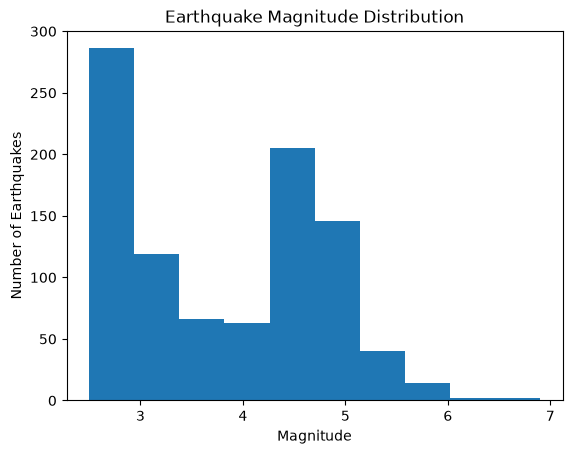

In [12]:
magnitudes = [
    record["magnitude"]
    for record in data
    if record["magnitude"] is not None
]

plt.hist(magnitudes, bins=10)
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquake Magnitude Distribution")
plt.show()

In [13]:
types = {}

for record in data:
    event_type = record["type"]

    if event_type not in types:
        types[event_type] = 0

    types[event_type] += 1

print("Event types:")
print(types)

Event types:
{'earthquake': 943}


In [14]:
strongest = sorted(
    data,
    key=lambda record: record["magnitude"],
    reverse=True
)

print("Top 5 strongest earthquakes:")

for record in strongest[:5]:
    print(
        record["magnitude"],
        "-",
        record["place"]
    )

Top 5 strongest earthquakes:
6.9 - 9 km WNW of Pematangsiantar, Indonesia
6.7 - 31 km NW of Aniso, Peru
6.2 - Scotia Sea
6.1 - 56 km NNE of Port-Olry, Vanuatu
6 - 145 km N of Caluula, Somalia


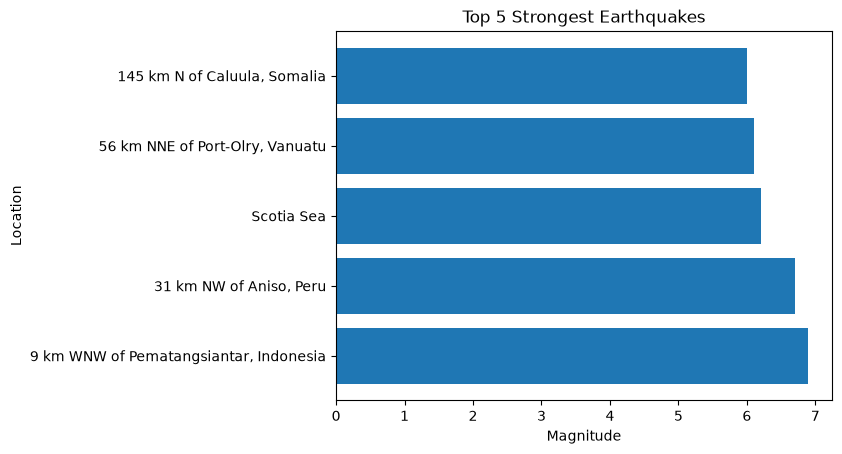

In [16]:
top5 = strongest[:5]

labels = [record["place"] for record in top5]
values = [record["magnitude"] for record in top5]

plt.barh(labels, values)

plt.xlabel("Magnitude")
plt.ylabel("Location")
plt.title("Top 5 Strongest Earthquakes")

plt.show()

In [17]:
duplicates = len(data) - len(set(record["id"] for record in data))

print("Duplicate records:", duplicates)

Duplicate records: 0


In [18]:
magnitude_ranges = {
    "2.5 - 3.0": 0,
    "3.0 - 4.0": 0,
    "4.0 - 5.0": 0,
    "5.0 - 6.0": 0,
    "6.0+": 0
}

for record in data:
    magnitude = record["magnitude"]

    if magnitude < 3:
        magnitude_ranges["2.5 - 3.0"] += 1
    elif magnitude < 4:
        magnitude_ranges["3.0 - 4.0"] += 1
    elif magnitude < 5:
        magnitude_ranges["4.0 - 5.0"] += 1
    elif magnitude < 6:
        magnitude_ranges["5.0 - 6.0"] += 1
    else:
        magnitude_ranges["6.0+"] += 1

print(magnitude_ranges)

{'2.5 - 3.0': 294, '3.0 - 4.0': 185, '4.0 - 5.0': 367, '5.0 - 6.0': 90, '6.0+': 7}


In [19]:
magnitude_ranges = {
    "2.5 - 3.0": 0,
    "3.0 - 4.0": 0,
    "4.0 - 5.0": 0,
    "5.0 - 6.0": 0,
    "6.0+": 0
}

for record in data:
    magnitude = record["magnitude"]

    if magnitude < 3:
        magnitude_ranges["2.5 - 3.0"] += 1
    elif magnitude < 4:
        magnitude_ranges["3.0 - 4.0"] += 1
    elif magnitude < 5:
        magnitude_ranges["4.0 - 5.0"] += 1
    elif magnitude < 6:
        magnitude_ranges["5.0 - 6.0"] += 1
    else:
        magnitude_ranges["6.0+"] += 1

print(magnitude_ranges)

{'2.5 - 3.0': 294, '3.0 - 4.0': 185, '4.0 - 5.0': 367, '5.0 - 6.0': 90, '6.0+': 7}


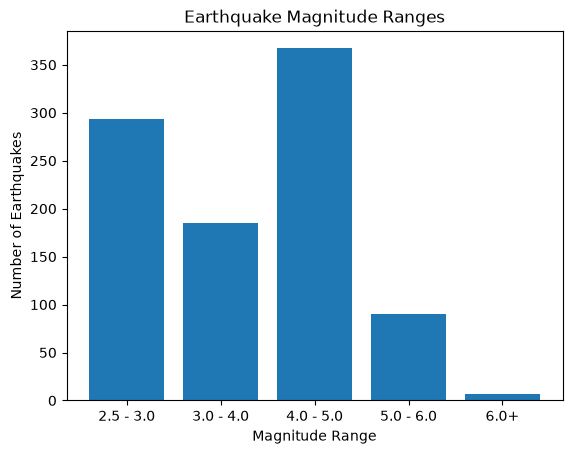

In [20]:
labels = list(magnitude_ranges.keys())
values = list(magnitude_ranges.values())

plt.bar(labels, values)

plt.xlabel("Magnitude Range")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquake Magnitude Ranges")

plt.show()

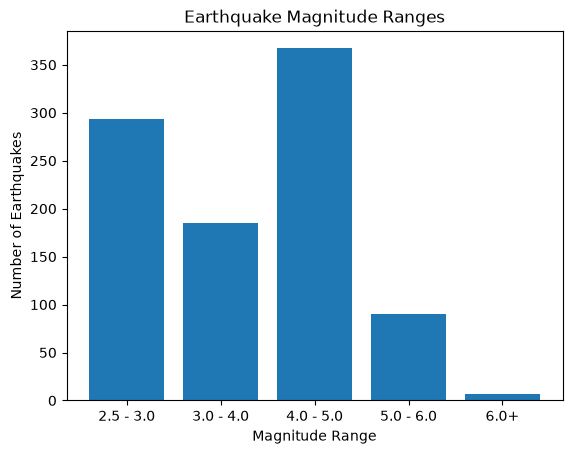

In [21]:
labels = list(magnitude_ranges.keys())
values = list(magnitude_ranges.values())

plt.bar(labels, values)

plt.xlabel("Magnitude Range")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquake Magnitude Ranges")

plt.show()

In [24]:
import json

with open("../data/raw/earthquakes.json", "r", encoding="utf-8") as file:
    raw_data = json.load(file)

depths = []

for record in raw_data["features"]:
    coordinates = record["geometry"]["coordinates"]

    if len(coordinates) >= 3:
        depth = coordinates[2]

        if depth is not None:
            depths.append(depth)

depth_min = min(depths)
depth_max = max(depths)
depth_mean = sum(depths) / len(depths)

print("Depth records:", len(depths))
print("Depth minimum:", depth_min)
print("Depth maximum:", depth_max)
print("Depth mean:", depth_mean)

Depth records: 945
Depth minimum: -2.84
Depth maximum: 628.976
Depth mean: 46.37906105909923


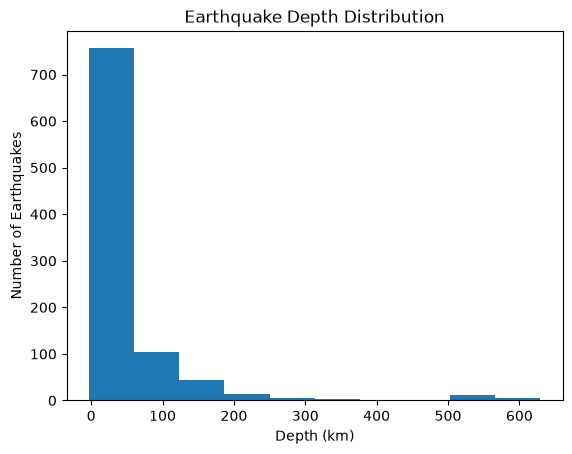

In [26]:
depths = []

for record in raw_data["features"]:
    coordinates = record["geometry"]["coordinates"]

    if len(coordinates) >= 3:
        depth = coordinates[2]

        if depth is not None:
            depths.append(depth)

plt.hist(depths, bins=10)

plt.xlabel("Depth (km)")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquake Depth Distribution")

plt.show()

In [27]:
shallowest = sorted(
    raw_data["features"],
    key=lambda record: record["geometry"]["coordinates"][2]
)

print("Top 5 Shallowest Earthquakes:")

for record in shallowest[:5]:
    properties = record["properties"]
    depth = record["geometry"]["coordinates"][2]

    print(
        depth,
        "km -",
        properties["place"]
    )

Top 5 Shallowest Earthquakes:
-2.84 km - 2 km NNW of Little America, Wyoming
-1.93 km - 3 km NW of Little America, Wyoming
0 km - 55 km NW of Kodāri̇̄, Nepal
0 km - 55 km NW of Kodāri̇̄, Nepal
0.1 km - 13 km N of Mentasta Lake, Alaska


In [28]:
deepest = sorted(
    raw_data["features"],
    key=lambda record: record["geometry"]["coordinates"][2],
    reverse=True
)

print("Top 5 Deepest Earthquakes:")

for record in deepest[:5]:
    properties = record["properties"]
    depth = record["geometry"]["coordinates"][2]

    print(
        depth,
        "km -",
        properties["place"]
    )

Top 5 Deepest Earthquakes:
628.976 km - Vanuatu region
615.874 km - Fiji region
599.718 km - Fiji region
576.355 km - south of the Fiji Islands
571.282 km - 273 km E of Levuka, Fiji


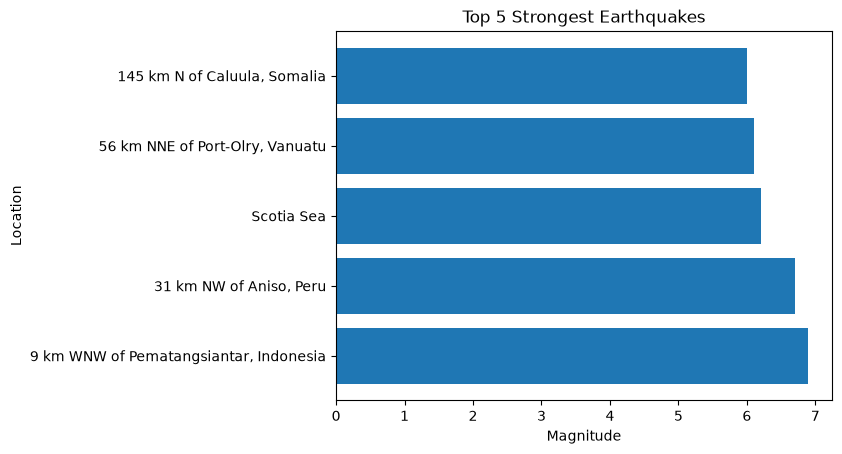

In [30]:
magnitudes = [
    record["magnitude"]
    for record in data
    if record["magnitude"] is not None
]

top5 = sorted(
    data,
    key=lambda record: record["magnitude"] if record["magnitude"] is not None else 0,
    reverse=True
)[:5]

labels = [record["place"] for record in top5]
values = [record["magnitude"] for record in top5]

plt.barh(labels, values)

plt.xlabel("Magnitude")
plt.ylabel("Location")
plt.title("Top 5 Strongest Earthquakes")

plt.show()

In [31]:
ids = [record["id"] for record in data]

duplicates = len(ids) - len(set(ids))

print("Duplicate records:", duplicates)

Duplicate records: 0


In [33]:
print("========== Final Summary ==========")

print("Total processed records:", len(data))
print("Minimum magnitude:", min(magnitudes))
print("Maximum magnitude:", max(magnitudes))
print("Average magnitude:", sum(magnitudes) / len(magnitudes))

print("Minimum depth:", depth_min)
print("Maximum depth:", depth_max)
print("Average depth:", depth_mean)

print("Duplicate records:", duplicates)

========== Final Summary ==========
Total processed records: 943
Minimum magnitude: 2.5
Maximum magnitude: 6.9
Average magnitude: 3.7863948759945543
Minimum depth: -2.84
Maximum depth: 628.976
Average depth: 46.37906105909923
Duplicate records: 0


In [34]:
summary = {
    "total_records": len(data),
    "minimum_magnitude": min(magnitudes),
    "maximum_magnitude": max(magnitudes),
    "average_magnitude": sum(magnitudes) / len(magnitudes),
    "minimum_depth": depth_min,
    "maximum_depth": depth_max,
    "average_depth": depth_mean,
    "duplicate_records": duplicates
}

with open(
    "../data/processed/summary.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(summary, file, indent=4)

print("Summary saved successfully!")

Summary saved successfully!
